CHECKING REPAIRABLE AND UNREPAIRABLE SIMULATIONS IN SEQUENCE

Determining the Mean Uptime and Downtime of a Component

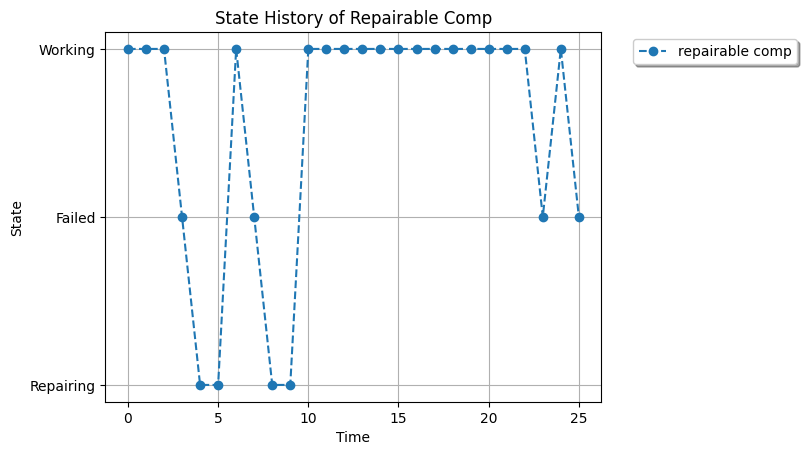

Uptime: 17.00
Downtime: 8.00
Availability: 0.6800
Mean Down Time (MDT): 2.33 time units
Mean Up Time (MUT): 4.25 time units


In [ ]:
from component_objects.component_exponential import ExponentialComponent
import numpy as np

sim_time = 25
dt = 1
comp = ExponentialComponent(name="repairable comp", MTTF=10, MTTR=4)
comp.simulate(t_end=sim_time, dt=dt, repairable=True)
# comp.simulate(t_end=sim_time/4, dt=dt, repairable=False)
# comp.simulate(t_end=sim_time/4, dt=dt, repairable=True)
# comp.simulate(t_end=sim_time/4, dt=dt, repairable=False)
comp.plot_history()

# check the time steps in history are unique and length is correct
assert len(set(comp.history[:,0])) ==  sim_time/dt +1

# analyze uptime and downtime (skipping initial state)
uptime = np.sum(comp.history[1:,1] == 1) * dt
downtime = np.sum(comp.history[1:,1] != 1) * dt
print(f"Uptime: {uptime:.2f}")
print(f"Downtime: {downtime:.2f}")

# calculate availability
availability = uptime / (uptime + downtime)
print(f"Availability: {availability:.4f}")

# determine mean down time (MDT)
downtime_periods = []
in_downtime = False
for i in range(1, len(comp.history)):
    if comp.history[i,1] != 1:
        if not in_downtime:
            in_downtime = True
            start_time = comp.history[i,0]
    else:
        if in_downtime:
            in_downtime = False
            end_time = comp.history[i,0]
            downtime_periods.append(end_time - start_time) 

mean_down_time = np.mean(downtime_periods) if downtime_periods else 0
print(f"Mean Down Time (MDT): {mean_down_time:.2f} time units")

# determine mean up time (MUT)
uptime_periods = []
in_uptime = False
for i in range(1, len(comp.history)):
    if comp.history[i,1] == 1:
        if not in_uptime:
            in_uptime = True
            start_time = comp.history[i,0]
    else:
        if in_uptime:
            in_uptime = False
            end_time = comp.history[i,0]
            uptime_periods.append(end_time - start_time)
mean_up_time = np.mean(uptime_periods) if uptime_periods else 0
print(f"Mean Up Time (MUT): {mean_up_time:.2f} time units")

In [24]:
print(comp.history[-1])

[12.  0.]


Verifying Simulation + Repairs

In [ ]:
from component_objects.component_weibull import WeibullComponent
import numpy as np
import matplotlib.pyplot as plt

# initialize a component and simulate a single repair 
comp = WeibullComponent(name="Comp1", shape=2.0, MTTF=10.0, MTTR=7.0)

# simulate component in repairable mode for 30 time units then non-repairable for 20 time units
comp.simulate(t_end= 30, dt=1, repairable=True)
comp.simulate(t_end=20, dt=1, repairable=False)
# print(comp.history)

# simulate component operation until a repair is conducted
# comp.simulate_until_repair(dt=1)

# plot the component history    
ax = comp.plot_history()
ax.set_ylim(-1.1, 1.1)
plt.show()

# print(comp.history)


Testing Repair

In [ ]:
from system_objects.series_system import SeriesSystem
# from system_objects.parallel_system import ParallelSystem
from component_objects.component_weibull import WeibullComponent
import numpy as np
import matplotlib.pyplot as plt

# initialize a series system of 3 components 

comp1 = WeibullComponent(name="Comp1", shape=2.0, MTTF=1000.0, MTTR=50.0)
comp2 = WeibullComponent(name="Comp2", shape=2.0, MTTF=1000.0, MTTR=50.0)
comp3 = WeibullComponent(name="Comp3", shape=2.0, MTTF=1000.0, MTTR=50.0)

series_system = SeriesSystem(
    name="SeriesSystem",
    components=[comp1, comp2, comp3]
)

# simulate n repairs and plot the repair times
n_repairs = 100
repair_times = []
for _ in range(n_repairs):
    repair_time, __ = series_system.repair()
    repair_times.append(repair_time)

plt.hist(repair_times, bins=5, alpha=0.7, color='blue')

K out of N system Repair

In [ ]:
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_weibull import WeibullComponent

import matplotlib.pyplot as plt

comp1 = WeibullComponent(name="Comp1", shape=2.0, MTTF=1000.0, MTTR=10.0)
comp2 = WeibullComponent(name="Comp2", shape=2.0, MTTF=1000.0, MTTR=10.0)
comp3 = WeibullComponent(name="Comp3", shape=2.0, MTTF=1000.0, MTTR=10.0)

kooN_system = KOutOfNSystem(
    name="KOutOfNSystem",
    components=[comp1, comp2, comp3],
    k=2
)

# simulate the first 10 repair times for each component and the system 
# max_repair_times = []
# min_repair_times = []
sys_repair_times = []
repair_times = [ [] for i in range(len(kooN_system.components)) ]
print(repair_times)

for i in range(10):
    sys_repair_time, all_repair_times = kooN_system.repair()
    sys_repair_times.append(sys_repair_time)
    for j in range(len(kooN_system.components)):
        repair_times[j].append(all_repair_times[j])
    # max_repair_times.append(all_repair_times[-1])
    # min_repair_times.append(all_repair_times[0])
    
# plot the system repair as a line and the component repair times as points
plt.figure()
plt.plot(repair_times[0], '.b', label="Component 1 Repair Time")
plt.plot(repair_times[1], '.g', label="Component 2 Repair Time")
plt.plot(repair_times[2], '.r', label="Component 3 Repair Time")
plt.plot(sys_repair_times, '--k', label="System Repair Time")

# plt.scatter(range(len(max_repair_times)), max_repair_times, label="Max Component Repair Time", s=50)
# plt.scatter(range(len(min_repair_times)), min_repair_times, label="Min Component Repair Time", s=50)
plt.xlabel("Simulation Iteration")
plt.ylabel("Repair Time")
plt.legend()
plt.title("System and Component Repair Times")
plt.show()

Testing Exponential Component Reliability Functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from component_objects.component_exponential import ExponentialComponent

t = np.array(range(0,51,1)) # time array
exp_comp = ExponentialComponent("test comp", MTTF=10, MTTR=2)

f_t = exp_comp.f_t(t)
plt.figure(figsize=(7,3))
plt.title("PDF: f(t)")
plt.plot(t, f_t)

R_t = exp_comp.R_t(t)
plt.figure(figsize=(7,3))
plt.title("Reliability Function: R(t)")
plt.plot(t, R_t)

z_t = exp_comp.z_t(t)
plt.figure(figsize=(7,3))
plt.title("Failure Rate: z(t)")
plt.plot(t, z_t)

Testing Weibull Component Reliability Functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from component_objects.component_weibull import WeibullComponent

num_test_comps = 1000

t = np.array(range(0,51,1)) # time array
f_ts = np.zeros((num_test_comps, len(t)))
R_ts = np.zeros_like(f_ts)
z_ts= np.zeros_like(f_ts)
for i in range(num_test_comps):
    weibull_comp = WeibullComponent("test comp", MTTF=10, MTTR=2, shape= 10) # shape default = 2 (wear out behavior)

    f_ts[i] = weibull_comp.f_t(t)
    R_ts[i] = weibull_comp.R_t(t)
    z_ts[i] = weibull_comp.z_t(t)
     

f_t = np.mean(f_ts, axis=0)
plt.figure(figsize=(7,3))
plt.title("PDF: f(t)")
plt.plot(t, f_t)

R_t = np.mean(R_ts, axis=0)
plt.figure(figsize=(7,3))
plt.title("Reliability Function: R(t)")
plt.plot(t, R_t)

z_t = np.mean(z_ts, axis=0)
plt.figure(figsize=(7,3))
plt.title("Failure Rate: z(t)")
plt.plot(t, z_t)

Initialize two different types of Components (exponential and weibull)

In [ ]:
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

# import logging
import matplotlib.pyplot as plt
import numpy as np

# set logging level here
# logging.basicConfig(level=logging.WARNING)

# simulate an exponential component
pump = ExponentialComponent(name="Pump A", MTTF=100, MTTR=10)
pump.simulate(t_end=500, dt=0.1)  # 500 time units, 1 per step

# simulate a weibull component
pump2 = WeibullComponent(name="Pump B", MTTF=100, MTTR=10, shape=1.5)
pump2.simulate(t_end=500, dt=1)  # 500 time units, 1 per step

# plot the histories of both components in a single plot
plt.figure(figsize=(5, 3))
pump.plot_history()
pump2.plot_history()
plt.title("Test Components State Histories")

Simulation 1000 comps of a specified distribution and plot histogram

In [ ]:
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

import numpy as np
import matplotlib.pyplot as plt

# simulate 1000 exponential components and record their failure times
n = 1000

# distribution = "exponential"
distribution = "exponential"
failure_times = np.zeros(n)
for i in range(n):
    #initialize component
    if distribution == "exponential":
        pump = ExponentialComponent(name="Pump A", MTTF=100, MTTR=10)
    if distribution == "weibull":
        pump = WeibullComponent(name="Pump B", MTTF=100, MTTR=10, shape=1.5)
    failure_times[i] = pump.time_to_failure

# plot histogram of failure times
plt.figure(figsize=(5, 3))
plt.hist(failure_times, bins=30, density=True, alpha=0.7, color='blue')
plt.xlabel("Failure Time")
plt.ylabel("Density")
plt.title(f"Histogram of Failure Times for 1000 {distribution.capitalize()} Components")
plt.grid()

Simulating a Repairable Component

In [ ]:
from component_objects.component_weibull import WeibullComponent
import numpy as np

# initialize a weibull component
pump = WeibullComponent(name="Pump A", MTTF=100, MTTR=10, shape=1.5)
pump.simulate(t_end=10000, dt=1, repairable=True)  # 500 time units, 1 per step

# plot the history of the component
pump.plot_history()



states = pump.history[:, 1]

# failure events: working → failed
failure_idx = np.where((states[:-1] == 1) & (states[1:] == 0))[0] + 1

# repair completions: repair → working
repair_done_idx = np.where((states[:-1] == -1) & (states[1:] == 1))[0] + 1

working_steps_between_failures = []

for f in failure_idx:
    # find most recent repair completion before this failure
    prev_repairs = repair_done_idx[repair_done_idx < f]

    start = prev_repairs[-1] if len(prev_repairs) > 0 else 0
    end = f

    working_steps_between_failures.append(
        np.sum(states[start:end] == 1)
    )

n_failures = len(working_steps_between_failures)

simulated_MTTF = np.mean(working_steps_between_failures) * pump.dt
simulated_MTTR = np.sum(states == -1) / n_failures * pump.dt

print("Number of failures:", n_failures)
print("Average working steps per life:", np.mean(working_steps_between_failures))
print("Simulated MTTF:", simulated_MTTF)
print("Simulated MTTR:", simulated_MTTR)

